# Chapter 12. Deep Computer Vision Using Convolutional Neural Networks

### Some important imports

In [1]:

from packaging.version import Version
import torch

assert Version(torch.__version__) >= Version("2.6.0")

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [3]:

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Convolution Layers

### Implementing Convolutional Layers with PyTorch

In [4]:
import numpy as np
import torch
from sklearn.datasets import load_sample_images

sample_images = np.stack(load_sample_images()["images"])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255.0

In [5]:
sample_images.shape

torch.Size([2, 427, 640, 3])

### Let's permute the dimensions from [batch, height, width, channels] to [batch, channels, height, width], as PyTorch expects

In [6]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

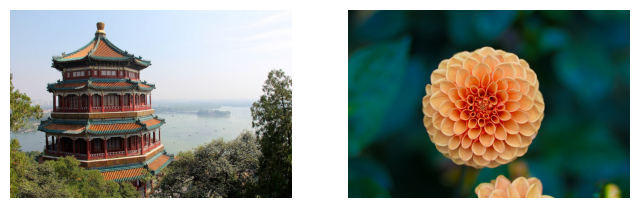

In [7]:

def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, image in enumerate(sample_images_permuted):
    plt.subplot(1, 2, index + 1)
    plot_image(image)

In [8]:
import torchvision
import torchvision.transforms.v2 as T

In [9]:
#Now let's rescale the pixel values from 0-255 to 0-1, and center crop them to small 70×120 images:
cropped_images = T.CenterCrop((70, 120))(sample_images_permuted)

In [10]:
cropped_images.shape

torch.Size([2, 3, 70, 120])

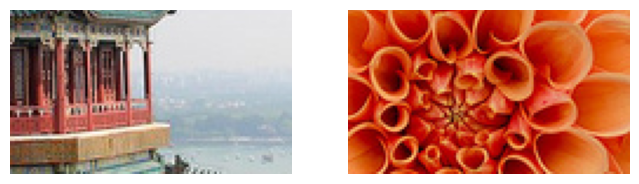

In [11]:

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plot_image(cropped_images[0])
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])

### Let’s create a convolutional layer with 32 filters, each of size 7 × 7 (using kernel_size=7, which is equivalent to using kernel_size=(7 ,7)), and apply this layer to our small batch of two images:

In [12]:
import torch.nn as nn

torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
fmaps = conv_layer(cropped_images)

In [13]:
fmaps.shape

torch.Size([2, 32, 64, 114])

> The output shape is similar to the input shape, with two main differences. First, there are 32 channels instead of 3. This is because we set out_channels=32, so we get 32 output feature maps: instead of the intensity of red, green, and blue at each location, we now have the intensity of each feature at each location. Second, the height and width have both shrunk by 6 pixels. This is due to the fact that the nn.Conv2d layer does not use any zero-padding by default, which means that we lose a few pixels on the sides of the output feature maps, depending on the size of the filters. In this case, since the kernel size is 7, we lose 6 pixels horizontally and 6 pixels vertically (i.e., 3 pixels on each side).


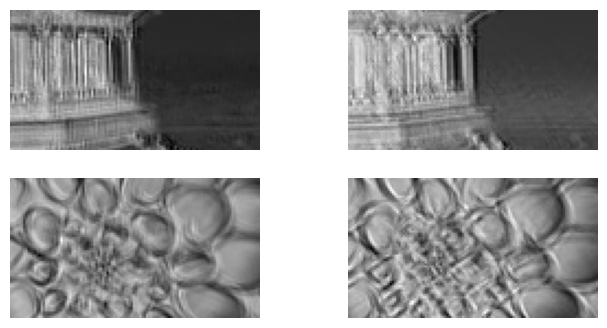

In [14]:

# extra code – displays the two output feature maps for each image

plt.figure(figsize=(8, 4))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, fmap_idx].detach(), cmap="gray")
        plt.axis("off")

plt.show()

# As you can see, randomly generated filters typically act like edge detectors, which is great since that's a useful tool in image processing, and that's the type of filters that a convolutional layer typically starts with. Then, during training, it gradually learns improved filters to recognize useful patterns for the task.

In [15]:
# zero padding 
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7,
                        padding="same")
fmaps = conv_layer(cropped_images)

In [16]:
fmaps.shape

torch.Size([2, 32, 70, 120])

In [17]:
# extra code – shows the output shape when we set strides=2
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, stride=2,
                        padding=3)
fmaps = conv_layer(cropped_images)
fmaps.shape

torch.Size([2, 32, 35, 60])

In [18]:
conv_layer.weight.shape
# The weight tensor is 4D, and its shape is [output_channels,input_channels, kernel_height, kernel_width]

torch.Size([32, 3, 7, 7])

In [19]:
conv_layer.bias.shape
# The bias tensor is 1D, and its shape is [output_channels]

torch.Size([32])

## Pooling Layers

### Implementing Pooling Layers with PyTorch

#### Max pooling

In [20]:
max_pool = nn.MaxPool2d(kernel_size=2)

In [21]:
output_max = max_pool(cropped_images)

In [22]:
avg_pool = nn.AvgPool2d(kernel_size=2)

In [23]:
output_avg = avg_pool(cropped_images)

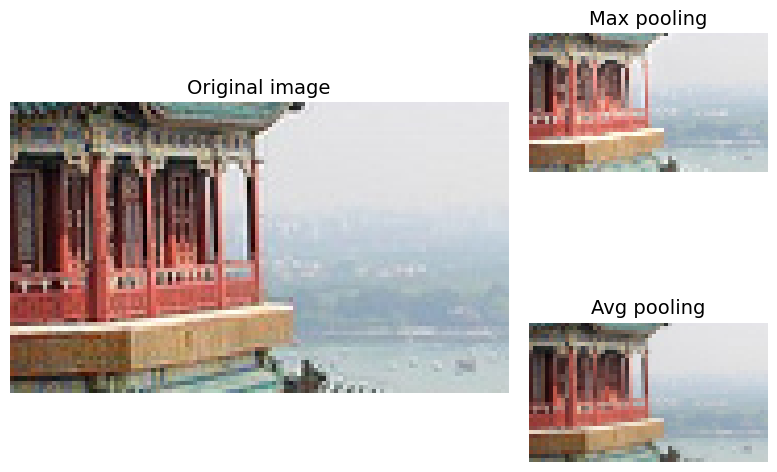

In [24]:
# extra code – this cells shows what max pooling with stride = 2 looks like

fig = plt.figure(figsize=(8, 6))

ax1 = plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=2)
ax1.imshow(cropped_images[0].permute(1, 2, 0))
ax1.axis('off')
ax1.set_title("Original image")

ax2 = plt.subplot2grid((2, 3), (0, 2))
ax2.imshow(output_max[0].permute(1, 2, 0))
ax2.axis('off')
ax2.set_title("Max pooling")

ax3 = plt.subplot2grid((2, 3), (1, 2))
ax3.imshow(output_avg[0].permute(1, 2, 0))
ax3.axis('off')
ax3.set_title("Avg pooling")

plt.tight_layout()
plt.show()

### Depth-wise pooling

In [25]:
import torch.nn.functional as F

class DepthMaxPool2(torch.nn.Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding

    def forward(self, inputs):
        batch, channels, height, width = inputs.shape
        Z = inputs.view(batch, channels, height * width)  # merge spatial dims
        Z = Z.permute(0, 2, 1)  # switch spatial and channels dims
        Z = F.max_pool1d(Z, kernel_size=self.kernel_size, stride=self.stride,
                            padding=self.padding)  # compute max pool
        Z = Z.permute(0, 2, 1)  # switch back spatial and channels dims
        return Z.view(batch, -1, height, width)  # unmerge spatial dims

### Global Average Pooling

In [26]:
# First implementation, not very convenient

global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))
output= global_avg_pool(cropped_images)

In [27]:
# Second implementation (recommended)

global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)
output = global_avg_pool(cropped_images)

In [28]:
# Third implementation, without using a module

output = cropped_images.mean(dim=(2, 3), keepdim=True)

## CNN Architectures

# typical cnn architecture 
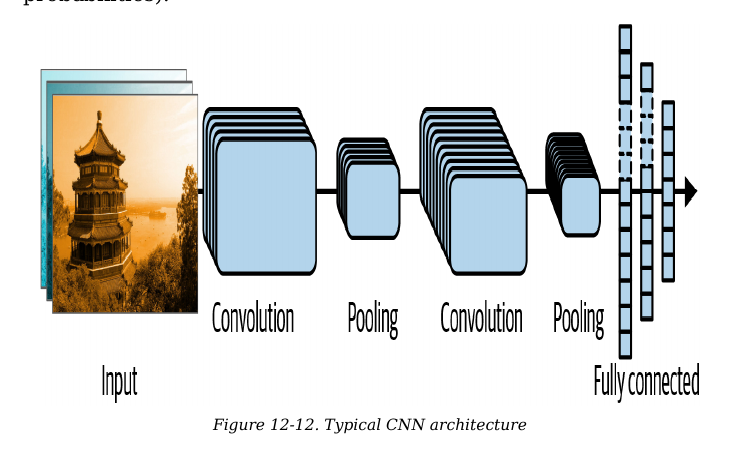

## Tackling Fashion MNIST With a CNN

In [29]:

from functools import partial

torch.manual_seed(42)  # extra code – ensure reproducibility
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")
model = nn.Sequential(
    DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
).to(device)

In [30]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
            n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
                f"train loss: {history['train_losses'][-1]:.4f}, "
                f"train metric: {history['train_metrics'][-1]:.4f}, "
                f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [31]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

In [32]:

from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [33]:
n_epochs = 10
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/10, train loss: 0.8171, train metric: 0.7001, valid metric: 0.8446
Epoch 2/10, train loss: 0.4846, train metric: 0.8301, valid metric: 0.8714
Epoch 3/10, train loss: 0.4114, train metric: 0.8591, valid metric: 0.8838
Epoch 4/10, train loss: 0.3590, train metric: 0.8776, valid metric: 0.8764
Epoch 5/10, train loss: 0.3337, train metric: 0.8866, valid metric: 0.8916
Epoch 6/10, train loss: 0.3093, train metric: 0.8955, valid metric: 0.8926
Epoch 7/10, train loss: 0.2878, train metric: 0.9034, valid metric: 0.8978
Epoch 8/10, train loss: 0.2716, train metric: 0.9077, valid metric: 0.8986
Epoch 9/10, train loss: 0.2671, train metric: 0.9122, valid metric: 0.8972
Epoch 10/10, train loss: 0.2533, train metric: 0.9149, valid metric: 0.9032


## LeNet-5

### The famous LeNet-5 architecture had the following layers:
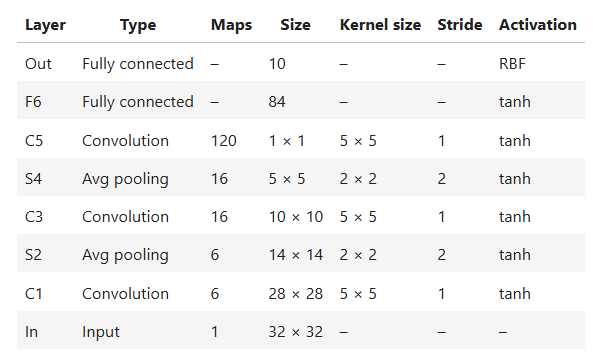

#### There were a few tweaks here and there, which don't really matter much anymore, but in case you are interested, here they are:

> MNIST images are 28 × 28 pixels, but they are zero-padded to 32 × 32 pixels and normalized before being fed to the network. The rest of the network does not use any padding, which is why the size keeps shrinking as the image progresses through the network

> The average pooling layers are slightly more complex than usual: each neuron computes the mean of its inputs, then multiplies the result by a learnable coefficient (one per map) and adds a learnable bias term (again, one per map), then finally applies the activation function.

> Most neurons in C3 maps are connected to neurons in only three or four S2 maps (instead of all six S2 maps). See table 1 (page 8) in the original paper for details.

> The output layer is a bit special: instead of computing the matrix multiplication of the inputs and the weight vector, each neuron outputs the square of the Euclidian distance between its input vector and its weight vector. Each output measures how much the image belongs to a particular digit class. The cross-entropy cost function is now preferred, as it penalizes bad predictions much more, producing larger gradients and converging faster.


## Alex-net

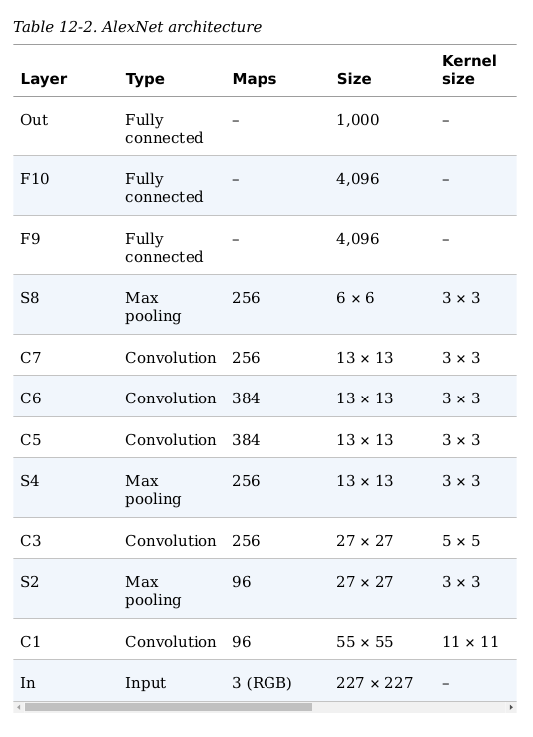

AlexNet wasn't just "bigger"; it introduced several tricks that are standard today:

It was Deep: It had 8 layers (5 convolutional, 3 fully connected). While this seems small now, at the time, it was considered very deep compared to predecessors like LeNet.

ReLU Activation: Before AlexNet, networks used complex curves (Sigmoid/Tanh) for activation. AlexNet used ReLU (Rectified Linear Unit).

Simple explanation: If the number is negative, make it 0. If it's positive, keep it as is.

Benefit: It made training 6x faster.

Dropout: This was a new technique to prevent Overfitting (memorizing the training data).

Analogy: During training, AlexNet randomly "turns off" 50% of its neurons. This forces the remaining neurons to learn robust features on their own without relying on their neighbors.

GPUs: It was the first major network trained on GPUs (Graphics Processing Units). It used two GTX 580s (gaming cards) to crunch the massive amount of math required.

Data Augmentation: To get more training data, they artificially expanded their dataset by flipping images horizontally and shifting them slightly. This taught the network that a "cat" is still a "cat" even if it is facing left or right.

## GoogLeNet

> Inception Module

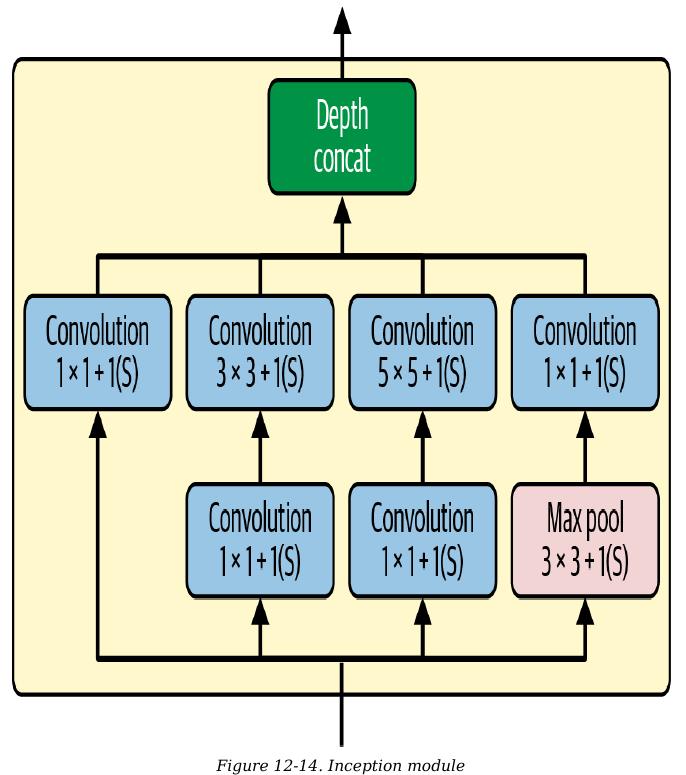

> It's Architecture

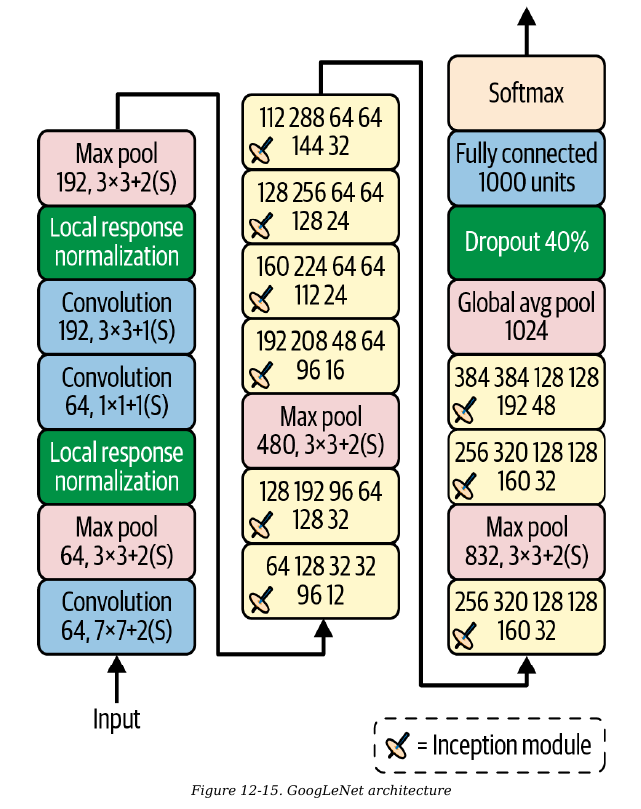

## ResNet

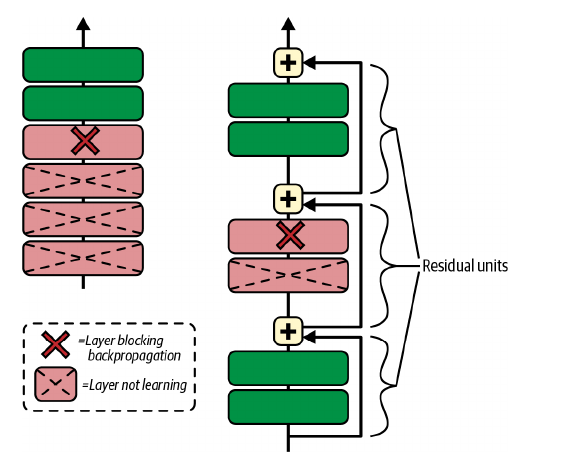

> Regular deep neural network (left) and deep residual network (right)

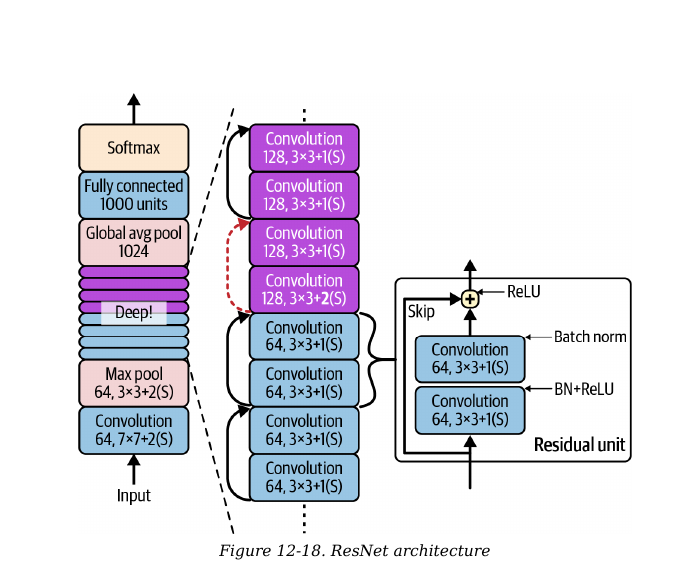

> Now let’s look at ResNet’s architecture . It is surprisingly simple. It starts and ends exactly like GoogLeNet (except without a dropout layer), and in between is just a very deep stack of residual units. Each residual unit is composed of two convolutional layers (and no pooling layer!), with batch normalization (BN) and ReLU activation, using 3 × 3 kernels and preserving spatial dimensions (stride 1, "same" padding).

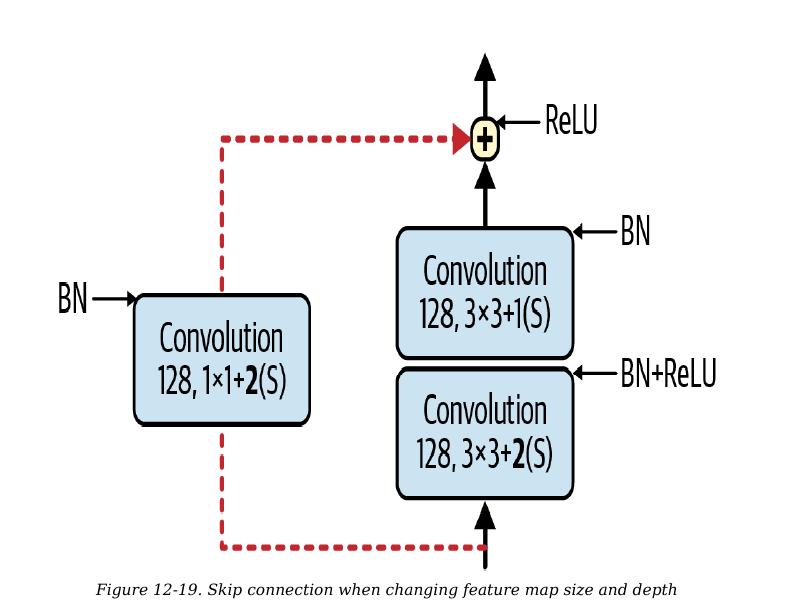

## Xception

In [35]:
# Separable Convolutional Layer
class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1,
                    padding=0):
        super().__init__()
        self.depthwise_conv = nn.Conv2d(
            in_channels, in_channels, kernel_size, stride=stride,
            padding=padding, groups=in_channels)
        self.pointwise_conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, inputs):
        return self.pointwise_conv(self.depthwise_conv(inputs))

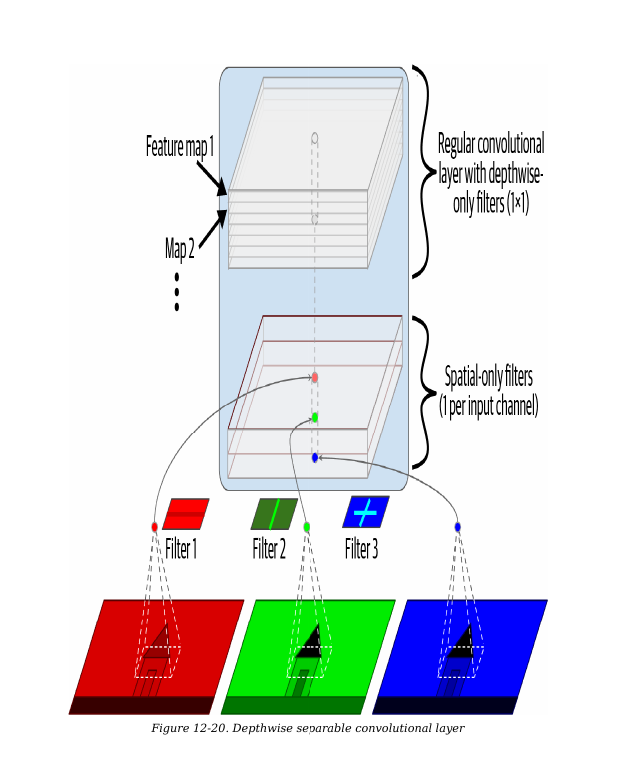